# 1. Business Understanding

## Business Context

In the FMCG industry, launching a new product can expand the product portfolio and create additional sales opportunities. However, a new product may also shift demand away from existing products within the same portfolio, creating a potential product cannibalization effect.

At the same time, the ability to forecast demand is important for supporting product launch decisions, inventory planning, pricing, and promotional planning.

This project analyzes FMCG sales data to understand product sales patterns, price and promotion responses, changes in existing product performance following the introduction of newer SKUs, and the factors that can be used to predict future demand.

## Main Objective

The objective is to build an analytical workflow that helps answer the following questions:

1. How does product demand change over time?
2. How are price and promotional activities associated with quantity sold?
3. Is there an indication of changes in existing product sales following the introduction of a new SKU?
4. Which factors can be used to predict product demand?
5. How can the analytical findings be translated into recommendations for product launch decisions?

## Analytical Scope

The project covers the following stages:

- Data understanding
- Data cleaning and validation
- Exploratory data analysis
- Product lifecycle analysis
- Price response analysis
- Product cannibalization analysis
- Demand forecasting
- Model evaluation
- Business recommendations

## Analytical Principle

Cannibalization analysis is treated as a data-driven indication based on observed sales patterns rather than direct evidence of a causal relationship without appropriate statistical testing.

Demand forecasting will be evaluated using time-aware validation to preserve the chronological order of observations and avoid using future information to predict the past.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
BASE_DIR = Path.cwd().parent

DATA_PATH = (
    BASE_DIR
    / "data"
    / "raw"
    / "FMCG_2022_2024.csv"
)

PROCESSED_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
ASSETS_DIR = BASE_DIR / "assets"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ASSETS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project directory :", BASE_DIR)
print("Dataset path      :", DATA_PATH)
print("Dataset exists    :", DATA_PATH.exists())

Project directory : e:\One Day One Project\fmcg smart launch intelligence
Dataset path      : e:\One Day One Project\fmcg smart launch intelligence\data\raw\FMCG_2022_2024.csv
Dataset exists    : True


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (190757, 14)


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [4]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows    : 190757
Columns : 14

Column names:
['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region', 'pack_type', 'price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty', 'units_sold']


In [13]:
df.shape

(190757, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190757 non-null  object 
 1   sku              190757 non-null  object 
 2   brand            190757 non-null  object 
 3   segment          190757 non-null  object 
 4   category         190757 non-null  object 
 5   channel          190757 non-null  object 
 6   region           190757 non-null  object 
 7   pack_type        190757 non-null  object 
 8   price_unit       190757 non-null  float64
 9   promotion_flag   190757 non-null  int64  
 10  delivery_days    190757 non-null  int64  
 11  stock_available  190757 non-null  int64  
 12  delivered_qty    190757 non-null  int64  
 13  units_sold       190757 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 20.4+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,190757,1076,2024-07-30,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,190757,30,MI-006,8221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,190757,14,SnBrand2,26775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,190757,13,Yogurt-Seg1,26851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,190757,5,Yogurt,72707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,190757,3,Retail,63688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,190757,3,PL-North,63645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_type,190757,3,Carton,63671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_unit,190757.0,NaN,NaN,NaN,5.251979,2.166705,1.5,3.38,5.25,7.13,9.0
promotion_flag,190757.0,NaN,NaN,NaN,0.1492,0.356287,0.0,0.0,0.0,0.0,1.0


In [7]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

missing_summary

,Missing_Count,Missing_Percentage
date,0,0.0
sku,0,0.0
brand,0,0.0
segment,0,0.0
category,0,0.0
channel,0,0.0
region,0,0.0
pack_type,0,0.0
price_unit,0,0.0
promotion_flag,0,0.0


In [8]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [9]:
for column in [
    "sku",
    "brand",
    "category"
]:
    
    if column in df.columns:
        print(
            f"{column}:",
            df[column].nunique()
        )

sku: 30
brand: 14
category: 5


In [10]:
# Distribusi SKU
if "sku" in df.columns:

    sku_summary = (
        df.groupby(
            "sku",
            as_index=False
        )
        .agg(
            First_Date=("date", "min"),
            Last_Date=("date", "max"),
            Total_Units_Sold=("units_sold", "sum"),
            Active_Days=("date", "nunique")
        )
        .sort_values("First_Date")
    )

    sku_summary.head(20)

In [14]:
sku_summary.head(20)

,sku,First_Date,Last_Date,Total_Units_Sold,Active_Days
2,MI-006,2022-01-21,2024-12-31,132623,1076
7,MI-026,2022-01-22,2024-12-31,152324,1075
29,YO-029,2022-02-28,2024-12-31,177798,1038
21,YO-005,2022-03-13,2024-12-31,176095,1025
23,YO-012,2022-03-29,2024-12-31,170575,1009
24,YO-014,2022-04-10,2024-12-31,148845,997
19,YO-001,2022-04-13,2024-12-31,146646,994
8,RE-004,2022-04-17,2024-12-31,149559,990
9,RE-007,2022-05-02,2024-12-31,146705,975
10,RE-015,2022-05-11,2024-12-31,144534,966


In [11]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Start date:", df["date"].min())
print("End date  :", df["date"].max())
print("Missing date:", df["date"].isna().sum())

Start date: 2022-01-21 00:00:00
End date  : 2024-12-31 00:00:00
Missing date: 0


In [12]:
core_columns = [
    "price_unit",
    "promotion_flag",
    "units_sold"
]

for column in core_columns:

    if column in df.columns:

        print(f"\n--- {column} ---")

        print(
            "Missing:",
            df[column].isna().sum()
        )

        print(
            "Unique:",
            df[column].nunique()
        )

        if pd.api.types.is_numeric_dtype(df[column]):

            print(
                "Min:",
                df[column].min()
            )

            print(
                "Max:",
                df[column].max()
            )


--- price_unit ---
Missing: 0
Unique: 751
Min: 1.5
Max: 9.0

--- promotion_flag ---
Missing: 0
Unique: 2
Min: 0
Max: 1

--- units_sold ---
Missing: 0
Unique: 135
Min: -25
Max: 139


In [15]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Data type after conversion:")
print(df["date"].dtype)

print("\nDate range:")
print("Start date :", df["date"].min())
print("End date   :", df["date"].max())

print("\nMissing dates:", df["date"].isna().sum())

Data type after conversion:
datetime64[ns]

Date range:
Start date : 2022-01-21 00:00:00
End date   : 2024-12-31 00:00:00

Missing dates: 0


In [16]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

if duplicate_rows == 0:
    print("No duplicate rows found.")
else:
    print("Duplicate rows detected.")

Duplicate rows: 0
No duplicate rows found.


In [17]:
validation_summary = pd.DataFrame({
    "Column": [
        "price_unit",
        "promotion_flag",
        "delivery_days",
        "stock_available",
        "delivered_qty",
        "units_sold"
    ],
    "Negative_Count": [
        (df["price_unit"] < 0).sum(),
        (df["promotion_flag"] < 0).sum(),
        (df["delivery_days"] < 0).sum(),
        (df["stock_available"] < 0).sum(),
        (df["delivered_qty"] < 0).sum(),
        (df["units_sold"] < 0).sum()
    ]
})

validation_summary

,Column,Negative_Count
0,price_unit,0
1,promotion_flag,0
2,delivery_days,0
3,stock_available,3
4,delivered_qty,3
5,units_sold,3


In [18]:
print("Promotion flag unique values:")
print(sorted(df["promotion_flag"].unique()))

Promotion flag unique values:
[0, 1]


In [19]:
missing_check = (
    df.isna()
    .sum()
    .reset_index()
)

missing_check.columns = ["Column", "Missing_Count"]

missing_check

,Column,Missing_Count
0,date,0
1,sku,0
2,brand,0
3,segment,0
4,category,0
5,channel,0
6,region,0
7,pack_type,0
8,price_unit,0
9,promotion_flag,0


In [20]:
print("Final dataset shape:", df.shape)
print("Duplicate rows    :", df.duplicated().sum())
print("Missing values    :", df.isna().sum().sum())
print("Date dtype        :", df["date"].dtype)

Final dataset shape: (190757, 14)
Duplicate rows    : 0
Missing values    : 0
Date dtype        : datetime64[ns]


# Exploratory Data Analysis


## Overall Sales Summary

In [26]:
# Create sales value
df["sales_value"] = df["price_unit"] * df["units_sold"]

overall_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Unique SKU",
        "Unique Brands",
        "Unique Segments",
        "Unique Categories",
        "Unique Channels",
        "Unique Regions",
        "Total Units Sold",
        "Total Sales Value",
        "Average Units Sold",
        "Average Unit Price"
    ],
    "Value": [
        len(df),
        df["sku"].nunique(),
        df["brand"].nunique(),
        df["segment"].nunique(),
        df["category"].nunique(),
        df["channel"].nunique(),
        df["region"].nunique(),
        df["units_sold"].sum(),
        df["sales_value"].sum(),
        df["units_sold"].mean(),
        df["price_unit"].mean()
    ]
})

overall_summary

,Metric,Value
0,Total Transactions,1.907570e+05
1,Unique SKU,3.000000e+01
2,Unique Brands,1.400000e+01
3,Unique Segments,1.300000e+01
4,Unique Categories,5.000000e+00
5,Unique Channels,3.000000e+00
6,Unique Regions,3.000000e+00
7,Total Units Sold,3.799824e+06
8,Total Sales Value,1.995130e+07
9,Average Units Sold,1.991971e+01


In [27]:
overall_summary["Value"] = overall_summary["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"
)

overall_summary

,Metric,Value
0,Total Transactions,"190,757.00"
1,Unique SKU,30.00
2,Unique Brands,14.00
3,Unique Segments,13.00
4,Unique Categories,5.00
5,Unique Channels,3.00
6,Unique Regions,3.00
7,Total Units Sold,"3,799,824.00"
8,Total Sales Value,"19,951,300.58"
9,Average Units Sold,19.92


## Monthly Sales Trend

In [28]:
monthly_sales = (
    df.assign(month=df["date"].dt.to_period("M").dt.to_timestamp())
      .groupby("month", as_index=False)
      .agg(
          Transactions=("sku", "size"),
          Units_Sold=("units_sold", "sum"),
          Sales_Value=("sales_value", "sum"),
          Avg_Price=("price_unit", "mean")
      )
)

monthly_sales

,month,Transactions,Units_Sold,Sales_Value,Avg_Price
0,2022-01-01,156,2095,10719.36,5.132308
1,2022-02-01,424,5647,29181.55,5.213137
2,2022-03-01,871,16353,86890.92,5.310402
3,2022-04-01,1533,33688,178015.88,5.254886
4,2022-05-01,2271,53165,273859.61,5.219899
5,2022-06-01,2466,63404,332079.35,5.237794
6,2022-07-01,2787,72471,379645.34,5.224898
7,2022-08-01,3084,69717,367004.50,5.269912
8,2022-09-01,3143,64527,341473.15,5.265689
9,2022-10-01,3759,68549,356889.53,5.248859


In [29]:
highest_sales_month = monthly_sales.loc[
    monthly_sales["Units_Sold"].idxmax()
]

lowest_sales_month = monthly_sales.loc[
    monthly_sales["Units_Sold"].idxmin()
]

print("Highest monthly units sold:")
print(highest_sales_month)

print("\nLowest monthly units sold:")
print(lowest_sales_month)

Highest monthly units sold:
month           2023-07-01 00:00:00
Transactions                   7140
Units_Sold                   170658
Sales_Value               891713.45
Avg_Price                  5.239772
Name: 18, dtype: object

Lowest monthly units sold:
month           2022-01-01 00:00:00
Transactions                    156
Units_Sold                     2095
Sales_Value                10719.36
Avg_Price                  5.132308
Name: 0, dtype: object


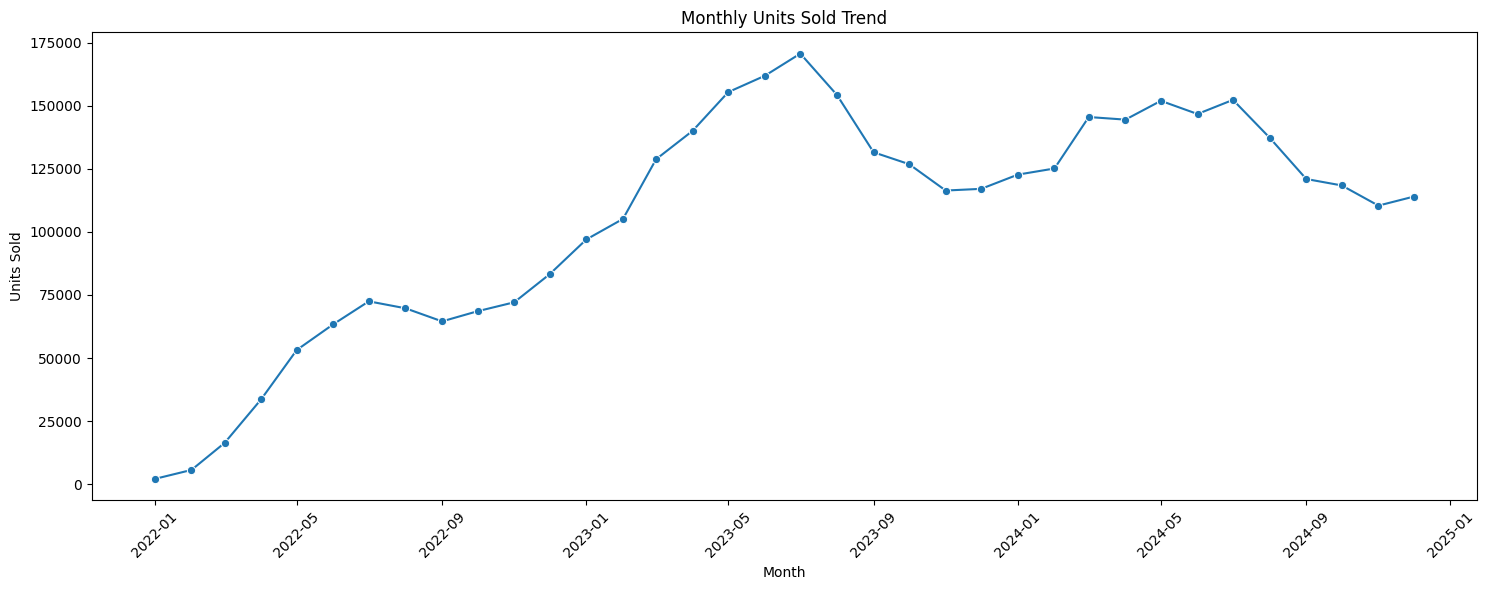

In [30]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="Units_Sold",
    marker="o"
)

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## SKU Performance

In [31]:
sku_performance = (
    df.groupby("sku", as_index=False)
      .agg(
          Transactions=("sku", "size"),
          Units_Sold=("units_sold", "sum"),
          Sales_Value=("sales_value", "sum"),
          Avg_Price=("price_unit", "mean"),
          Avg_Delivery_Days=("delivery_days", "mean")
      )
      .sort_values("Units_Sold", ascending=False)
)

sku_performance.head(15)

,sku,Transactions,Units_Sold,Sales_Value,Avg_Price,Avg_Delivery_Days
29,YO-029,7909,177798,931878.44,5.258590,3.006954
21,YO-005,7893,176095,913420.95,5.232430,3.019764
23,YO-012,7719,170575,899410.48,5.263013,2.995595
7,MI-026,8216,152324,796853.75,5.224004,2.989776
8,RE-004,7643,149559,792286.33,5.270156,2.989271
24,YO-014,7630,148845,786740.68,5.281128,2.991874
9,RE-007,7489,146705,771396.59,5.256604,3.024703
19,YO-001,7574,146646,777399.30,5.295236,3.025878
22,YO-009,6778,145236,755334.62,5.201093,3.016967
10,RE-015,7366,144534,759512.43,5.278002,2.984931


In [32]:
top_15_sku = sku_performance.head(15).copy()

top_15_sku

,sku,Transactions,Units_Sold,Sales_Value,Avg_Price,Avg_Delivery_Days
29,YO-029,7909,177798,931878.44,5.258590,3.006954
21,YO-005,7893,176095,913420.95,5.232430,3.019764
23,YO-012,7719,170575,899410.48,5.263013,2.995595
7,MI-026,8216,152324,796853.75,5.224004,2.989776
8,RE-004,7643,149559,792286.33,5.270156,2.989271
24,YO-014,7630,148845,786740.68,5.281128,2.991874
9,RE-007,7489,146705,771396.59,5.256604,3.024703
19,YO-001,7574,146646,777399.30,5.295236,3.025878
22,YO-009,6778,145236,755334.62,5.201093,3.016967
10,RE-015,7366,144534,759512.43,5.278002,2.984931


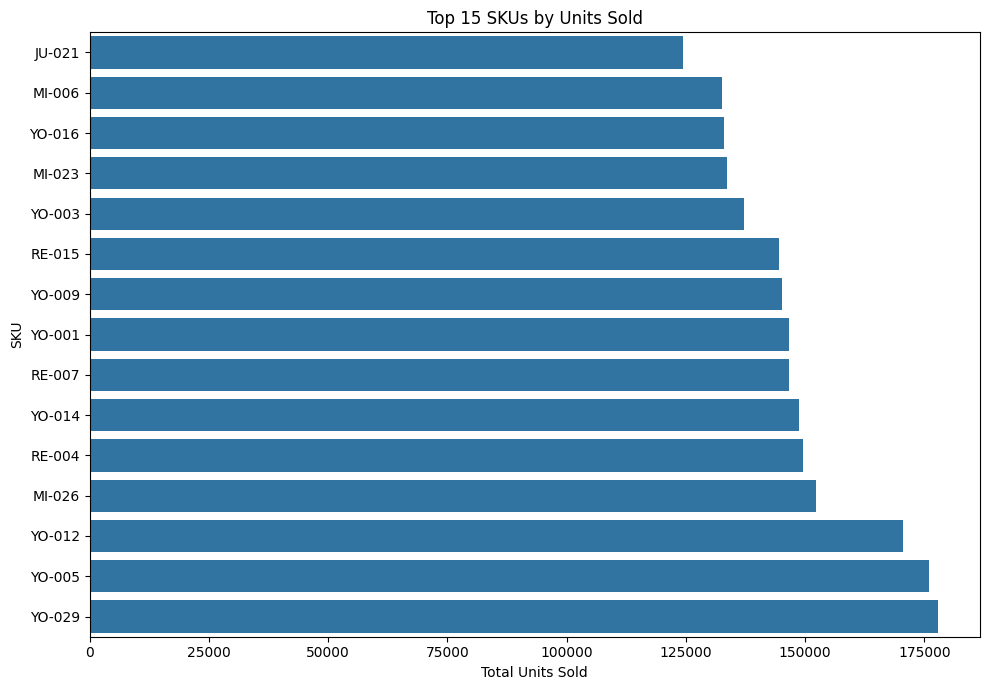

In [33]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_15_sku.sort_values("Units_Sold"),
    x="Units_Sold",
    y="sku"
)

plt.title("Top 15 SKUs by Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("SKU")
plt.tight_layout()
plt.show()

## Category Performance

In [34]:
category_performance = (
    df.groupby("category", as_index=False)
      .agg(
          Transactions=("sku", "size"),
          Units_Sold=("units_sold", "sum"),
          Sales_Value=("sales_value", "sum"),
          Avg_Price=("price_unit", "mean")
      )
      .sort_values("Units_Sold", ascending=False)
)

category_performance

,category,Transactions,Units_Sold,Sales_Value,Avg_Price
4,Yogurt,72707,1566582,8226193.31,5.260013
1,Milk,44595,782734,4095375.42,5.225782
2,ReadyMeal,34236,678834,3576329.02,5.272239
3,SnackBar,32276,647325,3401125.56,5.245678
0,Juice,6943,124349,652277.27,5.265496


In [35]:
category_performance["Sales_Share_%"] = (
    category_performance["Sales_Value"]
    / category_performance["Sales_Value"].sum()
    * 100
)

category_performance

,category,Transactions,Units_Sold,Sales_Value,Avg_Price,Sales_Share_%
4,Yogurt,72707,1566582,8226193.31,5.260013,41.231364
1,Milk,44595,782734,4095375.42,5.225782,20.526859
2,ReadyMeal,34236,678834,3576329.02,5.272239,17.925293
3,SnackBar,32276,647325,3401125.56,5.245678,17.047137
0,Juice,6943,124349,652277.27,5.265496,3.269347


## Channel Performance

In [36]:
channel_performance = (
    df.groupby("channel", as_index=False)
      .agg(
          Transactions=("sku", "size"),
          Units_Sold=("units_sold", "sum"),
          Sales_Value=("sales_value", "sum"),
          Avg_Price=("price_unit", "mean")
      )
      .sort_values("Units_Sold", ascending=False)
)

channel_performance["Sales_Share_%"] = (
    channel_performance["Sales_Value"]
    / channel_performance["Sales_Value"].sum()
    * 100
)

channel_performance

,channel,Transactions,Units_Sold,Sales_Value,Avg_Price,Sales_Share_%
1,E-commerce,63619,1268738,6653435.41,5.241760,33.348379
2,Retail,63688,1267296,6655592.06,5.256965,33.359189
0,Discount,63450,1263790,6642273.11,5.257220,33.292432


## Regional Performance

In [37]:
region_performance = (
    df.groupby("region", as_index=False)
      .agg(
          Transactions=("sku", "size"),
          Units_Sold=("units_sold", "sum"),
          Sales_Value=("sales_value", "sum")
      )
      .sort_values("Units_Sold", ascending=False)
)

region_performance["Sales_Share_%"] = (
    region_performance["Sales_Value"]
    / region_performance["Sales_Value"].sum()
    * 100
)

region_performance

,region,Transactions,Units_Sold,Sales_Value,Sales_Share_%
1,PL-North,63645,1270322,6664220.52,33.402437
2,PL-South,63567,1267592,6666229.81,33.412508
0,PL-Central,63545,1261910,6620850.25,33.185056


## Promotion Analysis

In [38]:
promotion_analysis = (
    df.groupby("promotion_flag", as_index=False)
      .agg(
          Transactions=("sku", "size"),
          Total_Units_Sold=("units_sold", "sum"),
          Avg_Units_Sold=("units_sold", "mean"),
          Total_Sales_Value=("sales_value", "sum"),
          Avg_Sales_Value=("sales_value", "mean"),
          Avg_Price=("price_unit", "mean")
      )
)

promotion_analysis["Promotion_Status"] = (
    promotion_analysis["promotion_flag"]
    .map({
        0: "No Promotion",
        1: "Promotion"
    })
)

promotion_analysis

,promotion_flag,Transactions,Total_Units_Sold,Avg_Units_Sold,Total_Sales_Value,Avg_Sales_Value,Avg_Price,Promotion_Status
0,0,162296,2830426,17.439900,14849830.28,91.498437,5.248836,No Promotion
1,1,28461,969398,34.060574,5101470.30,179.244239,5.269902,Promotion


In [39]:
promo_avg = promotion_analysis.loc[
    promotion_analysis["promotion_flag"] == 1,
    "Avg_Units_Sold"
].iloc[0]

non_promo_avg = promotion_analysis.loc[
    promotion_analysis["promotion_flag"] == 0,
    "Avg_Units_Sold"
].iloc[0]

difference_pct = (
    (promo_avg - non_promo_avg)
    / non_promo_avg
    * 100
)

print(f"Average units sold difference: {difference_pct:.2f}%")

Average units sold difference: 95.30%


## Price Analysis

In [40]:
price_summary = df["price_unit"].describe().to_frame()

price_summary

,price_unit
count,190757.000000
mean,5.251979
std,2.166705
min,1.500000
25%,3.380000
50%,5.250000
75%,7.130000
max,9.000000


In [41]:
df["price_group"] = pd.qcut(
    df["price_unit"],
    q=5,
    duplicates="drop"
)

price_group_analysis = (
    df.groupby("price_group", observed=False)
      .agg(
          Transactions=("sku", "size"),
          Avg_Price=("price_unit", "mean"),
          Avg_Units_Sold=("units_sold", "mean"),
          Total_Units_Sold=("units_sold", "sum")
      )
      .reset_index()
)

price_group_analysis

,price_group,Transactions,Avg_Price,Avg_Units_Sold,Total_Units_Sold
0,"(1.499, 3.0]",38242,2.251197,19.947178,762820
1,"(3.0, 4.5]",38146,3.752717,19.952289,761100
2,"(4.5, 6.01]",38329,5.259962,19.872760,761703
3,"(6.01, 7.5]",37975,6.763089,19.913733,756224
4,"(7.5, 9.0]",38065,8.253590,19.912702,757977


## Product Structure

In [42]:
product_structure = pd.DataFrame({
    "Dimension": [
        "SKU",
        "Brand",
        "Segment",
        "Category",
        "Channel",
        "Region",
        "Pack Type"
    ],
    "Unique_Count": [
        df["sku"].nunique(),
        df["brand"].nunique(),
        df["segment"].nunique(),
        df["category"].nunique(),
        df["channel"].nunique(),
        df["region"].nunique(),
        df["pack_type"].nunique()
    ]
})

product_structure

,Dimension,Unique_Count
0,SKU,30
1,Brand,14
2,Segment,13
3,Category,5
4,Channel,3
5,Region,3
6,Pack Type,3


# Product Lifecycle Analysis


Product lifecycle analysis is conducted to understand when each SKU first appears in the observed sales data, how long it remains active, and how its sales performance develops over the observation period.

The first observed sales date is used as a proxy for product introduction timing because the dataset does not provide an official product launch date.

The analysis also considers active days and sales performance to distinguish products with different lengths of market observation.

In [44]:
sku_lifecycle = (
    df.groupby(
        ["sku", "brand", "segment", "category"],
        as_index=False
    )
    .agg(
        First_Observed_Date=("date", "min"),
        Last_Observed_Date=("date", "max"),
        Active_Days=("date", "nunique"),
        Total_Units_Sold=("units_sold", "sum"),
        Total_Sales_Value=("sales_value", "sum"),
        Avg_Units_Per_Day=("units_sold", "mean"),
        Avg_Price=("price_unit", "mean")
    )
)

sku_lifecycle["Observed_Duration_Days"] = (
    sku_lifecycle["Last_Observed_Date"]
    - sku_lifecycle["First_Observed_Date"]
).dt.days + 1

sku_lifecycle = sku_lifecycle.sort_values(
    "First_Observed_Date"
)

sku_lifecycle.head(20)

,sku,brand,segment,category,First_Observed_Date,Last_Observed_Date,Active_Days,Total_Units_Sold,Total_Sales_Value,Avg_Units_Per_Day,Avg_Price,Observed_Duration_Days
2,MI-006,MiBrand1,Milk-Seg3,Milk,2022-01-21,2024-12-31,1076,132623,692133.59,16.132222,5.240337,1076
7,MI-026,MiBrand4,Milk-Seg2,Milk,2022-01-22,2024-12-31,1075,152324,796853.75,18.539922,5.224004,1075
29,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,2022-02-28,2024-12-31,1038,177798,931878.44,22.480465,5.258590,1038
21,YO-005,YoBrand2,Yogurt-Seg1,Yogurt,2022-03-13,2024-12-31,1025,176095,913420.95,22.310275,5.232430,1025
23,YO-012,YoBrand1,Yogurt-Seg2,Yogurt,2022-03-29,2024-12-31,1009,170575,899410.48,22.098070,5.263013,1009
24,YO-014,YoBrand4,Yogurt-Seg3,Yogurt,2022-04-10,2024-12-31,997,148845,786740.68,19.507864,5.281128,997
19,YO-001,YoBrand3,Yogurt-Seg1,Yogurt,2022-04-13,2024-12-31,994,146646,777399.30,19.361764,5.295236,994
8,RE-004,ReBrand1,ReadyMeal-Seg2,ReadyMeal,2022-04-17,2024-12-31,990,149559,792286.33,19.568102,5.270156,990
9,RE-007,ReBrand4,ReadyMeal-Seg1,ReadyMeal,2022-05-02,2024-12-31,975,146705,771396.59,19.589398,5.256604,975
10,RE-015,ReBrand4,ReadyMeal-Seg1,ReadyMeal,2022-05-11,2024-12-31,966,144534,759512.43,19.621776,5.278002,966


In [45]:
print("Total SKU:", sku_lifecycle["sku"].nunique())

print(
    "Earliest observed date:",
    sku_lifecycle["First_Observed_Date"].min().date()
)

print(
    "Latest observed date:",
    sku_lifecycle["Last_Observed_Date"].max().date()
)

print(
    "Average observed duration:",
    f"{sku_lifecycle['Observed_Duration_Days'].mean():,.2f} days"
)

print(
    "Median observed duration:",
    f"{sku_lifecycle['Observed_Duration_Days'].median():,.2f} days"
)

Total SKU: 30
Earliest observed date: 2022-01-21
Latest observed date: 2024-12-31
Average observed duration: 831.50 days
Median observed duration: 823.00 days


In [46]:
sku_lifecycle["Introduction_Year"] = (
    sku_lifecycle["First_Observed_Date"].dt.year
)

yearly_introduction = (
    sku_lifecycle
    .groupby("Introduction_Year", as_index=False)
    .agg(
        New_SKUs=("sku", "nunique"),
        Avg_Observed_Duration=("Observed_Duration_Days", "mean"),
        Avg_Units_Per_Day=("Avg_Units_Per_Day", "mean"),
        Total_Units_Sold=("Total_Units_Sold", "sum")
    )
)

yearly_introduction

,Introduction_Year,New_SKUs,Avg_Observed_Duration,Avg_Units_Per_Day,Total_Units_Sold
0,2022,20,922.4,19.815031,2795121
1,2023,10,649.7,20.284980,1004703


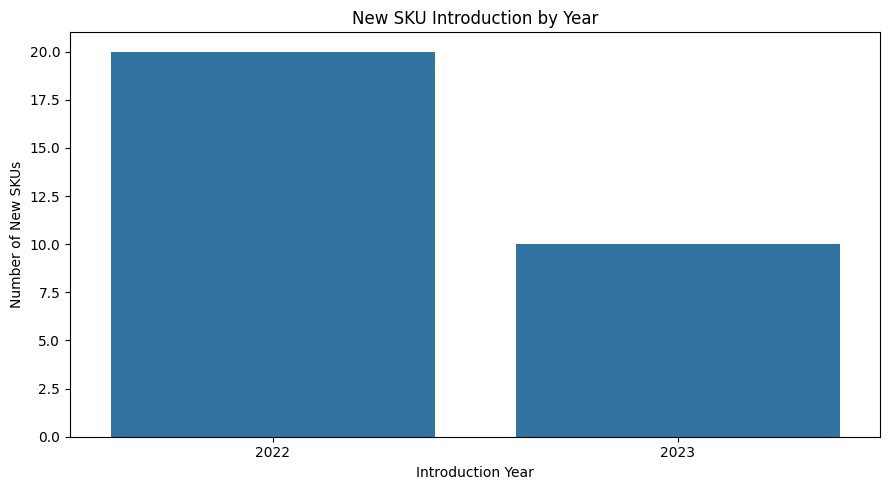

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=yearly_introduction,
    x="Introduction_Year",
    y="New_SKUs"
)

plt.title("New SKU Introduction by Year")
plt.xlabel("Introduction Year")
plt.ylabel("Number of New SKUs")

plt.tight_layout()
plt.show()

In [48]:
sku_lifecycle["Introduction_Month"] = (
    sku_lifecycle["First_Observed_Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_introduction = (
    sku_lifecycle
    .groupby("Introduction_Month", as_index=False)
    .agg(
        New_SKUs=("sku", "nunique")
    )
)

monthly_introduction

,Introduction_Month,New_SKUs
0,2022-01-01,2
1,2022-02-01,1
2,2022-03-01,2
3,2022-04-01,3
4,2022-05-01,2
5,2022-06-01,1
6,2022-07-01,1
7,2022-08-01,1
8,2022-09-01,2
9,2022-10-01,1


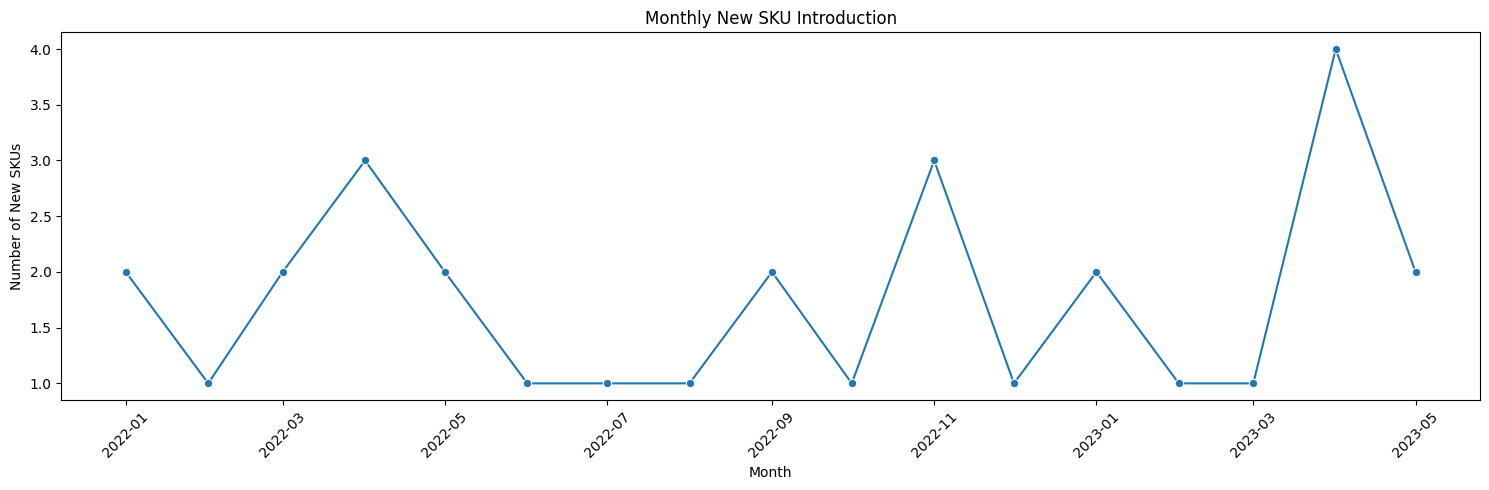

In [49]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_introduction,
    x="Introduction_Month",
    y="New_SKUs",
    marker="o"
)

plt.title("Monthly New SKU Introduction")
plt.xlabel("Month")
plt.ylabel("Number of New SKUs")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
shortest_lifecycle = (
    sku_lifecycle
    .sort_values("Observed_Duration_Days")
    .head(15)
)

shortest_lifecycle[
    [
        "sku",
        "brand",
        "segment",
        "category",
        "First_Observed_Date",
        "Last_Observed_Date",
        "Observed_Duration_Days",
        "Total_Units_Sold"
    ]
]

,sku,brand,segment,category,First_Observed_Date,Last_Observed_Date,Observed_Duration_Days,Total_Units_Sold
18,SN-030,SnBrand2,SnackBar-Seg1,SnackBar,2023-05-26,2024-12-31,586,95731
26,YO-018,YoBrand2,Yogurt-Seg1,Yogurt,2023-05-07,2024-12-31,605,99863
17,SN-028,SnBrand2,SnackBar-Seg1,SnackBar,2023-04-20,2024-12-31,622,101706
3,MI-008,MiBrand3,Milk-Seg2,Milk,2023-04-12,2024-12-31,630,82888
28,YO-024,YoBrand2,Yogurt-Seg3,Yogurt,2023-04-05,2024-12-31,637,109519
4,MI-011,MiBrand1,Milk-Seg2,Milk,2023-04-04,2024-12-31,638,84626
1,MI-002,MiBrand2,Milk-Seg1,Milk,2023-03-12,2024-12-31,661,95534
15,SN-019,SnBrand2,SnackBar-Seg1,SnackBar,2023-02-18,2024-12-31,683,109593
27,YO-020,YoBrand3,Yogurt-Seg2,Yogurt,2023-01-21,2024-12-31,711,121833
14,SN-013,SnBrand3,SnackBar-Seg2,SnackBar,2023-01-08,2024-12-31,724,103410


In [51]:
longest_lifecycle = (
    sku_lifecycle
    .sort_values(
        "Observed_Duration_Days",
        ascending=False
    )
    .head(15)
)

longest_lifecycle[
    [
        "sku",
        "brand",
        "segment",
        "category",
        "First_Observed_Date",
        "Last_Observed_Date",
        "Observed_Duration_Days",
        "Total_Units_Sold"
    ]
]

,sku,brand,segment,category,First_Observed_Date,Last_Observed_Date,Observed_Duration_Days,Total_Units_Sold
2,MI-006,MiBrand1,Milk-Seg3,Milk,2022-01-21,2024-12-31,1076,132623
7,MI-026,MiBrand4,Milk-Seg2,Milk,2022-01-22,2024-12-31,1075,152324
29,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,2022-02-28,2024-12-31,1038,177798
21,YO-005,YoBrand2,Yogurt-Seg1,Yogurt,2022-03-13,2024-12-31,1025,176095
23,YO-012,YoBrand1,Yogurt-Seg2,Yogurt,2022-03-29,2024-12-31,1009,170575
24,YO-014,YoBrand4,Yogurt-Seg3,Yogurt,2022-04-10,2024-12-31,997,148845
19,YO-001,YoBrand3,Yogurt-Seg1,Yogurt,2022-04-13,2024-12-31,994,146646
8,RE-004,ReBrand1,ReadyMeal-Seg2,ReadyMeal,2022-04-17,2024-12-31,990,149559
9,RE-007,ReBrand4,ReadyMeal-Seg1,ReadyMeal,2022-05-02,2024-12-31,975,146705
10,RE-015,ReBrand4,ReadyMeal-Seg1,ReadyMeal,2022-05-11,2024-12-31,966,144534


In [52]:
df = df.merge(
    sku_lifecycle[
        ["sku", "First_Observed_Date"]
    ],
    on="sku",
    how="left"
)

df["Product_Age_Days"] = (
    df["date"] - df["First_Observed_Date"]
).dt.days

df[[
    "date",
    "sku",
    "First_Observed_Date",
    "Product_Age_Days",
    "units_sold"
]].head()

,date,sku,First_Observed_Date,Product_Age_Days,units_sold
0,2022-01-21,MI-006,2022-01-21,0,9
1,2022-01-21,MI-006,2022-01-21,0,0
2,2022-01-21,MI-006,2022-01-21,0,8
3,2022-01-21,MI-006,2022-01-21,0,7
4,2022-01-21,MI-006,2022-01-21,0,12


In [53]:
df["Product_Age_Group"] = pd.cut(
    df["Product_Age_Days"],
    bins=[-1, 30, 90, 180, 365, 730, np.inf],
    labels=[
        "0-30 Days",
        "31-90 Days",
        "91-180 Days",
        "181-365 Days",
        "366-730 Days",
        "730+ Days"
    ]
)

In [54]:
age_performance = (
    df.groupby("Product_Age_Group", observed=False)
      .agg(
          Transactions=("sku", "size"),
          Unique_SKUs=("sku", "nunique"),
          Avg_Units_Sold=("units_sold", "mean"),
          Total_Units_Sold=("units_sold", "sum"),
          Avg_Sales_Value=("sales_value", "mean")
      )
      .reset_index()
)

age_performance

,Product_Age_Group,Transactions,Unique_SKUs,Avg_Units_Sold,Total_Units_Sold,Avg_Sales_Value
0,0-30 Days,7082,30,16.751341,118633,88.240757
1,31-90 Days,13792,30,22.448448,309609,117.431784
2,91-180 Days,20579,30,25.445843,523650,133.696579
3,181-365 Days,42398,30,19.830723,840783,103.981079
4,366-730 Days,77611,30,18.985453,1473480,99.668628
5,730+ Days,29295,20,18.217068,533669,95.970193


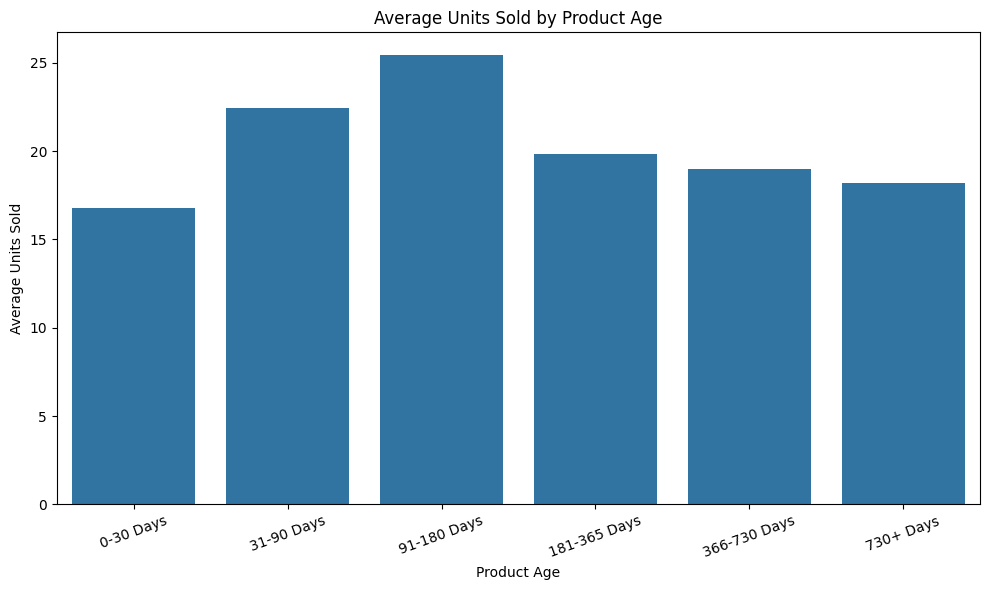

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_performance,
    x="Product_Age_Group",
    y="Avg_Units_Sold"
)

plt.title("Average Units Sold by Product Age")
plt.xlabel("Product Age")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# Price Elasticity Analysis

## SKU-Level Price & Demand Summary

In [56]:
sku_price_demand = (
    df.groupby("sku", as_index=False)
      .agg(
          Avg_Price=("price_unit", "mean"),
          Avg_Units_Sold=("units_sold", "mean"),
          Total_Units_Sold=("units_sold", "sum"),
          Price_Min=("price_unit", "min"),
          Price_Max=("price_unit", "max"),
          Price_Std=("price_unit", "std")
      )
)

sku_price_demand

,sku,Avg_Price,Avg_Units_Sold,Total_Units_Sold,Price_Min,Price_Max,Price_Std
0,JU-021,5.265496,17.909981,124349,1.5,9.00,2.182778
1,MI-002,5.235919,18.854154,95534,1.5,9.00,2.184712
2,MI-006,5.240337,16.132222,132623,1.5,9.00,2.166728
3,MI-008,5.209793,17.351476,82888,1.5,9.00,2.153069
4,MI-011,5.223298,17.402015,84626,1.5,9.00,2.146214
5,MI-022,5.240912,16.180989,101115,1.5,9.00,2.184456
6,MI-023,5.203219,18.553735,133624,1.5,9.00,2.184634
7,MI-026,5.224004,18.539922,152324,1.5,9.00,2.163871
8,RE-004,5.270156,19.568102,149559,1.5,9.00,2.154299
9,RE-007,5.256604,19.589398,146705,1.5,9.00,2.167615


In [57]:
price_demand_corr = (
    sku_price_demand[
        ["Avg_Price", "Avg_Units_Sold"]
    ]
    .corr()
)

price_demand_corr

,Avg_Price,Avg_Units_Sold
Avg_Price,1.000000,0.283891
Avg_Units_Sold,0.283891,1.000000


In [58]:
price_demand_corr = (
    sku_price_demand[
        ["Avg_Price", "Avg_Units_Sold"]
    ]
    .corr()
)

price_demand_corr

,Avg_Price,Avg_Units_Sold
Avg_Price,1.000000,0.283891
Avg_Units_Sold,0.283891,1.000000


## Price vs Demand

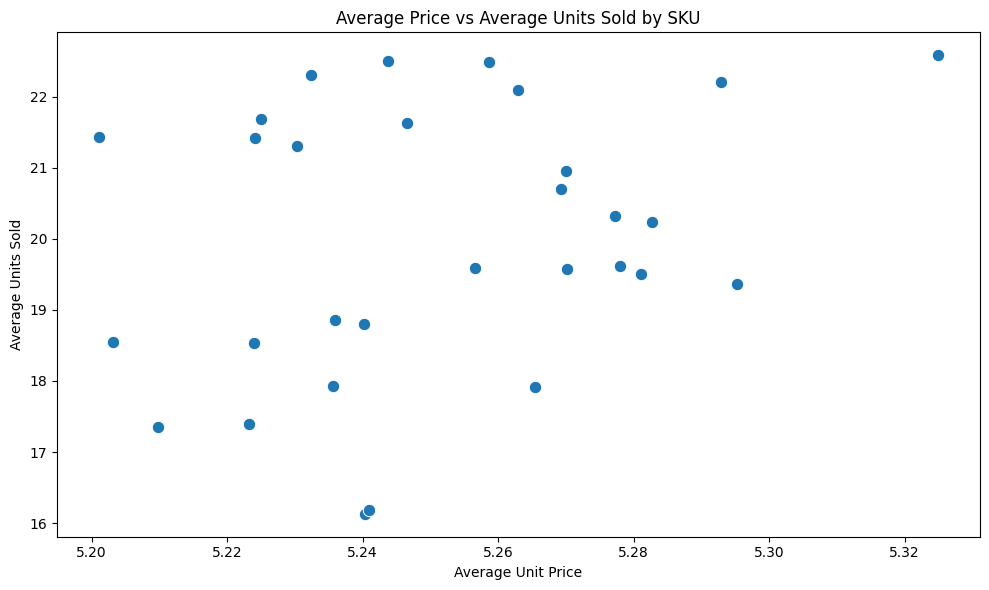

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sku_price_demand,
    x="Avg_Price",
    y="Avg_Units_Sold",
    s=80
)

plt.title("Average Price vs Average Units Sold by SKU")
plt.xlabel("Average Unit Price")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

elasticity_df = df[
    (df["price_unit"] > 0) &
    (df["units_sold"] > 0)
].copy()

elasticity_df["log_price"] = np.log(elasticity_df["price_unit"])
elasticity_df["log_units_sold"] = np.log(elasticity_df["units_sold"])

X = elasticity_df[["log_price"]]
y = elasticity_df["log_units_sold"]

elasticity_model = LinearRegression()
elasticity_model.fit(X, y)

elasticity = elasticity_model.coef_[0]
intercept = elasticity_model.intercept_

y_pred = elasticity_model.predict(X)
r2 = r2_score(y, y_pred)

print("OVERALL PRICE ELASTICITY ")
print(f"Elasticity coefficient : {elasticity:.4f}")
print(f"Intercept              : {intercept:.4f}")
print(f"R-squared              : {r2:.4f}")
print(f"Observations used      : {len(elasticity_df):,}")

OVERALL PRICE ELASTICITY 
Elasticity coefficient : -0.0010
Intercept              : 2.8776
R-squared              : 0.0000
Observations used      : 186,892


In [65]:
if elasticity < 0:
    direction = "negative"
else:
    direction = "positive"

print(f"\nObserved price-demand relationship: {direction}")

if elasticity < 0:
    print(
        f"A 1% increase in price is associated with an estimated "
        f"{abs(elasticity):.2f}% decrease in units sold."
    )
else:
    print(
        f"A 1% increase in price is associated with an estimated "
        f"{elasticity:.2f}% increase in units sold."
    )


Observed price-demand relationship: negative
A 1% increase in price is associated with an estimated 0.00% decrease in units sold.


In [66]:
sku_elasticity_results = []

for sku, group in df.groupby("sku"):

    group = group[
        (group["price_unit"] > 0) &
        (group["units_sold"] > 0)
    ].copy()

    # Minimal observations and price variation
    if len(group) < 30:
        continue

    if group["price_unit"].nunique() < 2:
        continue

    group["log_price"] = np.log(group["price_unit"])
    group["log_units_sold"] = np.log(group["units_sold"])

    X = group[["log_price"]]
    y = group["log_units_sold"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    sku_elasticity_results.append({
        "sku": sku,
        "Observations": len(group),
        "Price_Variation": group["price_unit"].std(),
        "Elasticity": model.coef_[0],
        "R_Squared": r2_score(y, y_pred),
        "Avg_Price": group["price_unit"].mean(),
        "Avg_Units_Sold": group["units_sold"].mean()
    })

sku_elasticity = pd.DataFrame(sku_elasticity_results)

sku_elasticity = sku_elasticity.sort_values(
    "Elasticity"
)

sku_elasticity

,sku,Observations,Price_Variation,Elasticity,R_Squared,Avg_Price,Avg_Units_Sold
21,YO-005,7716,2.171879,-0.029308,7.086642e-04,5.232041,22.822058
10,RE-015,7201,2.181956,-0.026829,6.940108e-04,5.284673,20.071379
12,RE-025,5876,2.159981,-0.023817,5.418069e-04,5.276222,20.708645
0,JU-021,6793,2.182586,-0.017567,2.585761e-04,5.266258,18.305462
2,MI-006,8054,2.167621,-0.015010,2.048101e-04,5.237585,16.466725
14,SN-013,5398,2.153230,-0.011870,1.185531e-04,5.244567,19.157095
27,YO-020,5316,2.154820,-0.011806,1.087017e-04,5.239255,22.918172
22,YO-009,6647,2.158588,-0.010481,9.322361e-05,5.203695,21.849857
26,YO-018,4489,2.169499,-0.006576,3.791959e-05,5.218004,22.246157
29,YO-029,7760,2.166533,-0.006551,3.428841e-05,5.254254,22.912113


In [67]:
def classify_elasticity(value):
    if value < -1:
        return "Elastic"
    elif value > -1:
        return "Inelastic"
    else:
        return "Unit Elastic"

sku_elasticity["Elasticity_Type"] = (
    sku_elasticity["Elasticity"]
    .apply(classify_elasticity)
)

sku_elasticity

,sku,Observations,Price_Variation,Elasticity,R_Squared,Avg_Price,Avg_Units_Sold,Elasticity_Type
21,YO-005,7716,2.171879,-0.029308,7.086642e-04,5.232041,22.822058,Inelastic
10,RE-015,7201,2.181956,-0.026829,6.940108e-04,5.284673,20.071379,Inelastic
12,RE-025,5876,2.159981,-0.023817,5.418069e-04,5.276222,20.708645,Inelastic
0,JU-021,6793,2.182586,-0.017567,2.585761e-04,5.266258,18.305462,Inelastic
2,MI-006,8054,2.167621,-0.015010,2.048101e-04,5.237585,16.466725,Inelastic
14,SN-013,5398,2.153230,-0.011870,1.185531e-04,5.244567,19.157095,Inelastic
27,YO-020,5316,2.154820,-0.011806,1.087017e-04,5.239255,22.918172,Inelastic
22,YO-009,6647,2.158588,-0.010481,9.322361e-05,5.203695,21.849857,Inelastic
26,YO-018,4489,2.169499,-0.006576,3.791959e-05,5.218004,22.246157,Inelastic
29,YO-029,7760,2.166533,-0.006551,3.428841e-05,5.254254,22.912113,Inelastic


In [68]:
sku_elasticity[
    [
        "sku",
        "Elasticity",
        "Elasticity_Type",
        "R_Squared",
        "Avg_Price",
        "Avg_Units_Sold"
    ]
].head(10)

,sku,Elasticity,Elasticity_Type,R_Squared,Avg_Price,Avg_Units_Sold
21,YO-005,-0.029308,Inelastic,0.000709,5.232041,22.822058
10,RE-015,-0.026829,Inelastic,0.000694,5.284673,20.071379
12,RE-025,-0.023817,Inelastic,0.000542,5.276222,20.708645
0,JU-021,-0.017567,Inelastic,0.000259,5.266258,18.305462
2,MI-006,-0.015010,Inelastic,0.000205,5.237585,16.466725
14,SN-013,-0.011870,Inelastic,0.000119,5.244567,19.157095
27,YO-020,-0.011806,Inelastic,0.000109,5.239255,22.918172
22,YO-009,-0.010481,Inelastic,0.000093,5.203695,21.849857
26,YO-018,-0.006576,Inelastic,0.000038,5.218004,22.246157
29,YO-029,-0.006551,Inelastic,0.000034,5.254254,22.912113


In [69]:
sku_elasticity.sort_values(
    "Elasticity",
    ascending=False
)[
    [
        "sku",
        "Elasticity",
        "Elasticity_Type",
        "R_Squared",
        "Avg_Price",
        "Avg_Units_Sold"
    ]
].head(10)

,sku,Elasticity,Elasticity_Type,R_Squared,Avg_Price,Avg_Units_Sold
3,MI-008,0.025347,Inelastic,0.000566,5.215936,17.673348
15,SN-019,0.023905,Inelastic,0.000504,5.275846,21.375658
6,MI-023,0.017450,Inelastic,0.000306,5.207850,18.921552
28,YO-024,0.016905,Inelastic,0.000238,5.317092,23.008193
5,MI-022,0.015837,Inelastic,0.000239,5.240463,16.557229
8,RE-004,0.014647,Inelastic,0.000212,5.269540,19.946519
23,YO-012,0.013177,Inelastic,0.000141,5.261116,22.613682
11,RE-017,0.011329,Inelastic,0.000122,5.272759,20.655423
16,SN-027,0.007033,Inelastic,0.000047,5.231812,18.303617
18,SN-030,0.006650,Inelastic,0.000040,5.232529,21.851404


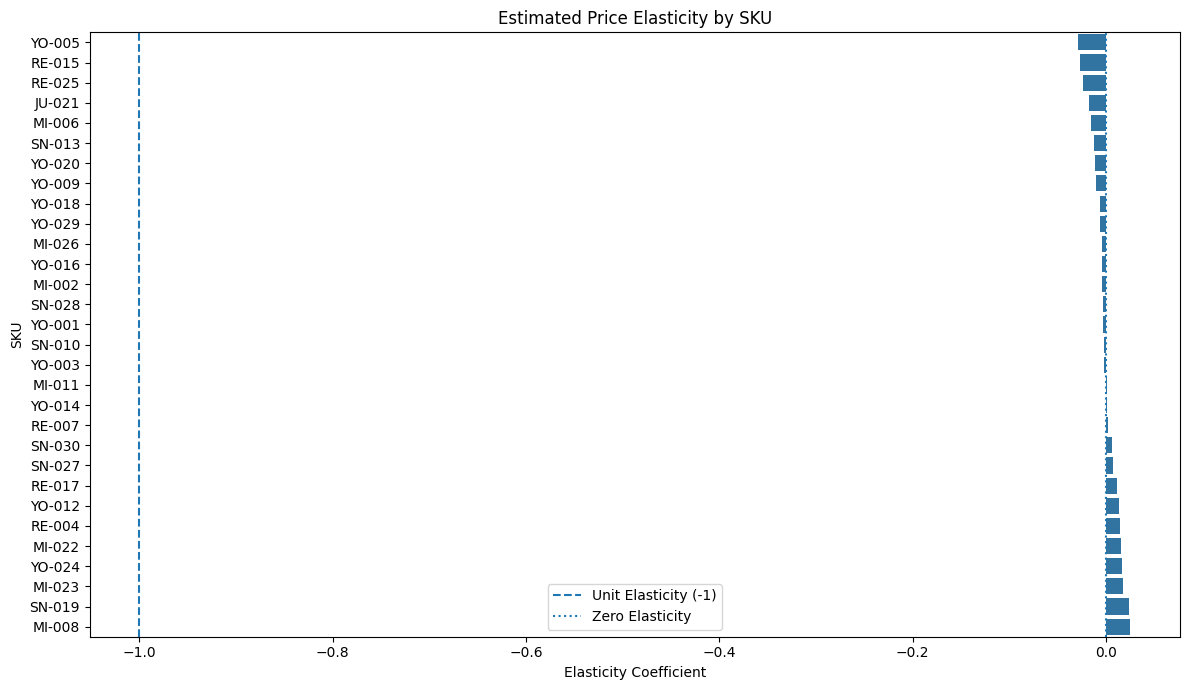

In [70]:
plt.figure(figsize=(12, 7))

plot_data = sku_elasticity.sort_values("Elasticity")

sns.barplot(
    data=plot_data,
    x="Elasticity",
    y="sku"
)

plt.axvline(
    x=-1,
    linestyle="--",
    label="Unit Elasticity (-1)"
)

plt.axvline(
    x=0,
    linestyle=":",
    label="Zero Elasticity"
)

plt.title("Estimated Price Elasticity by SKU")
plt.xlabel("Elasticity Coefficient")
plt.ylabel("SKU")
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
import statsmodels.formula.api as smf

elasticity_model_df = df[
    (df["price_unit"] > 0) &
    (df["units_sold"] > 0)
].copy()

elasticity_model_df["log_price"] = np.log(
    elasticity_model_df["price_unit"]
)

elasticity_model_df["log_units_sold"] = np.log(
    elasticity_model_df["units_sold"]
)

elasticity_model_df["month_num"] = (
    elasticity_model_df["date"].dt.month
)

elasticity_model_df["year_num"] = (
    elasticity_model_df["date"].dt.year
)

print("Observations used:", len(elasticity_model_df))

Observations used: 186892


In [72]:
formula = """
log_units_sold ~
log_price +
promotion_flag +
C(sku) +
C(channel) +
C(region) +
C(month_num) +
C(year_num)
"""

price_elasticity_model = smf.ols(
    formula=formula,
    data=elasticity_model_df
).fit(cov_type="HC3")

print(price_elasticity_model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_units_sold   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     1587.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:45:55   Log-Likelihood:            -1.1009e+05
No. Observations:              186892   AIC:                         2.203e+05
Df Residuals:                  186843   BIC:                         2.208e+05
Df Model:                          48                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [73]:
elasticity_coefficient = (
    price_elasticity_model.params["log_price"]
)

elasticity_pvalue = (
    price_elasticity_model.pvalues["log_price"]
)

model_r2 = price_elasticity_model.rsquared

elasticity_summary = pd.DataFrame({
    "Metric": [
        "Price Elasticity",
        "P-value",
        "R-squared",
        "Observations"
    ],
    "Value": [
        elasticity_coefficient,
        elasticity_pvalue,
        model_r2,
        len(elasticity_model_df)
    ]
})

elasticity_summary

,Metric,Value
0,Price Elasticity,-0.001905
1,P-value,0.366912
2,R-squared,0.296913
3,Observations,186892.000000


# Product Cannibalization Analysis